In [26]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


In [27]:
data = joblib.load("train_test_data.pkl")

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]


print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

report_results = {}

X_train shape: (226980, 30)
y_train shape: (226980,)
X_test shape: (56746, 30)
y_test shape: (56746,)


LogisticRegression

In [28]:
lr = LogisticRegression(random_state=42,max_iter=1000)

skf = StratifiedKFold(n_splits=5,random_state=42,shuffle=True,)
scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

cv_results = cross_validate(
    lr,
    X_train,
    y_train,
    cv = skf,
    scoring=scoring
)

print(f"Accuracy : {cv_results['test_accuracy'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall   : {cv_results['test_recall'].mean():.4f}")
print(f"F1       : {cv_results['test_f1'].mean():.4f}")

lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

report_results["Logistic Regression"] = [cv_results['test_precision'].mean(),cv_results['test_recall'].mean(),cv_results['test_f1'].mean()]


Accuracy : 0.9992
Precision: 0.8633
Recall   : 0.6056
F1       : 0.7096


Logistic Regression Evaluation 

accuracy_lr: 0.9991
precision_lr: 0.8462
recall_lr: 0.5789
f1_lr: 0.6875

TN:56641
FN:40
TP:55
FP:10


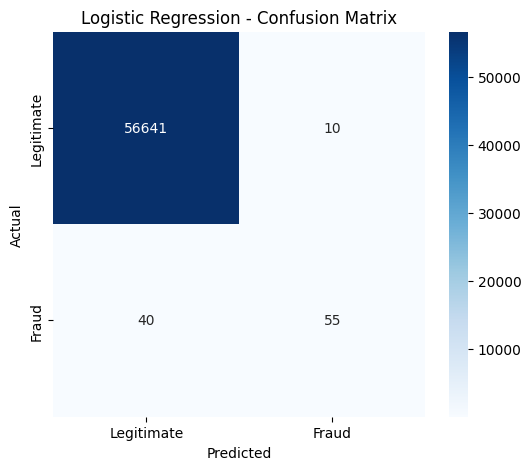

In [29]:
acc_lr = accuracy_score(y_test,y_pred_lr)
pre_lr = precision_score(y_test,y_pred_lr)
recall_lr = recall_score(y_test,y_pred_lr)
f1_lr = f1_score(y_test,y_pred_lr)
cm_lr = confusion_matrix(y_test,y_pred_lr)

print(f"accuracy_lr: {acc_lr:.4f}")
print(f"precision_lr: {pre_lr:.4f}")
print(f"recall_lr: {recall_lr:.4f}")
print(f"f1_lr: {f1_lr:.4f}\n")

TN, FP, FN, TP = cm_lr.ravel()
print(f"TN:{TN}")
print(f"FN:{FN}")
print(f"TP:{TP}")
print(f"FP:{FP}")


plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [30]:
data_not_scaled = joblib.load("train_test_data_not_scaled.pkl")

Xtrain_not_scaled ,Xtest_not_scaled ,ytrain_not_scaled ,ytest_not_scaled  = data_not_scaled["X_train"],data_not_scaled["X_test"],data_not_scaled["y_train"],data_not_scaled["y_test"]


KNN

Accuracy : 0.9995
Precision: 0.9159
Recall   : 0.7673
F1       : 0.8335

TN:56641
FN:40
TP:55
FP:10


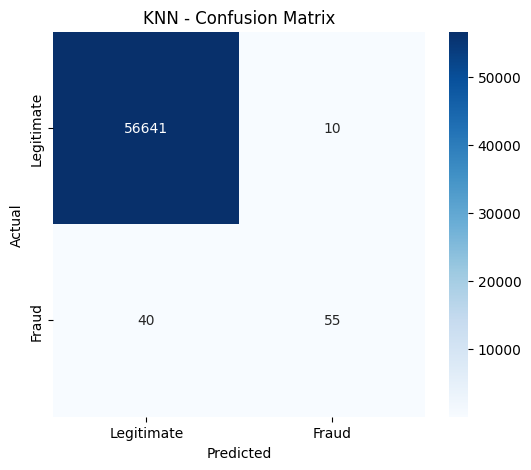

In [31]:
knn = KNeighborsClassifier(n_neighbors=5)

skf = StratifiedKFold(n_splits=5,random_state=42,shuffle=True,)
scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

cv_results = cross_validate(
    knn,
    X_train,
    y_train,
    cv = skf,
    scoring=scoring
)

print(f"Accuracy : {cv_results['test_accuracy'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall   : {cv_results['test_recall'].mean():.4f}")
print(f"F1       : {cv_results['test_f1'].mean():.4f}\n")

knn.fit(X_train,y_train)
y_pred_knn = knn.predict(X_test)


report_results["KNN-5"] = [cv_results['test_precision'].mean(),cv_results['test_recall'].mean(),cv_results['test_f1'].mean()]

cm_knn = confusion_matrix(y_test,y_pred_lr)

TN, FP, FN, TP = cm_knn.ravel()
print(f"TN:{TN}")
print(f"FN:{FN}")
print(f"TP:{TP}")
print(f"FP:{FP}")


plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Confusion Matrix")
plt.show()

Decision Tree Classifier

Accuracy : 0.9995
Precision: 0.9074
Recall   : 0.7698
F1       : 0.8324

TN:56641
FN:40
TP:55
FP:10


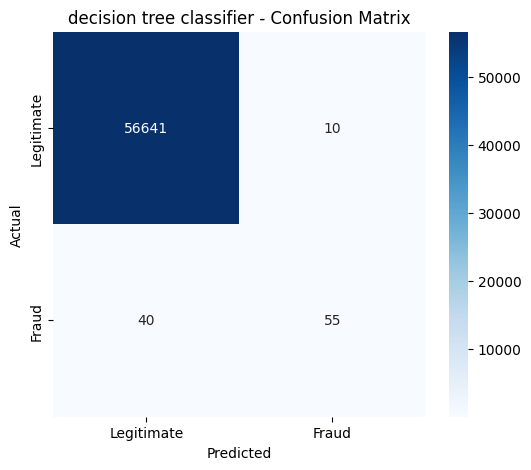

In [32]:
dtc = DecisionTreeClassifier(max_depth=5,random_state=42)

skf = StratifiedKFold(n_splits=5,random_state=42,shuffle=True,)
scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

cv_results = cross_validate(
    dtc,
    Xtrain_not_scaled,
    ytrain_not_scaled,
    cv = skf,
    scoring=scoring
)

print(f"Accuracy : {cv_results['test_accuracy'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall   : {cv_results['test_recall'].mean():.4f}")
print(f"F1       : {cv_results['test_f1'].mean():.4f}\n")

dtc.fit(Xtrain_not_scaled,ytrain_not_scaled)
y_pred_dtc = dtc.predict(Xtest_not_scaled)

report_results["DTC-5"] = [cv_results['test_precision'].mean(),cv_results['test_recall'].mean(),cv_results['test_f1'].mean()]

cm_dtc = confusion_matrix(y_test,y_pred_lr)

TN, FP, FN, TP = cm_dtc.ravel()
print(f"TN:{TN}")
print(f"FN:{FN}")
print(f"TP:{TP}")
print(f"FP:{FP}")


plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_dtc,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("decision tree classifier - Confusion Matrix")
plt.show()

In [33]:
results_df = pd.DataFrame(
    report_results,
    index=["Precision", "Recall", "F1"]
).T.reset_index()

results_df = results_df.rename(columns={"index": "Model"})

results_df.round(4)

,Model,Precision,Recall,F1
0,Logistic Regression,0.8633,0.6056,0.7096
1,KNN-5,0.9159,0.7673,0.8335
2,DTC-5,0.9074,0.7698,0.8324


Mandatory Experiment 1: Effect of Scaling

Accuracy : 0.9983
Precision: 0.8000
Recall   : 0.0132
F1       : 0.0260

TN:56651
FN:93
TP:2
FP:0


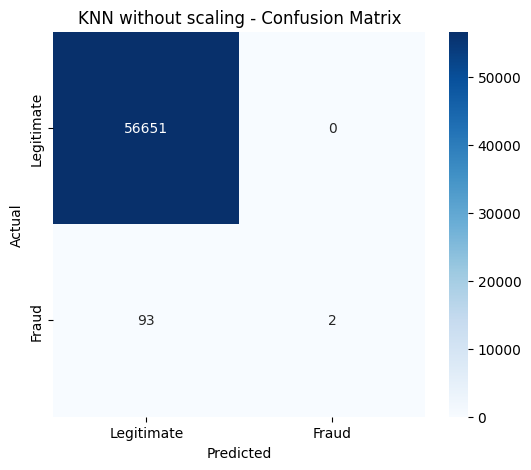

In [35]:
knn = KNeighborsClassifier(n_neighbors=5)

skf = StratifiedKFold(n_splits=5,random_state=42,shuffle=True,)
scoring = {
    "accuracy": "accuracy",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"
}

cv_results = cross_validate(
    knn,
    Xtrain_not_scaled,
    ytrain_not_scaled,
    cv = skf,
    scoring=scoring
)

print(f"Accuracy : {cv_results['test_accuracy'].mean():.4f}")
print(f"Precision: {cv_results['test_precision'].mean():.4f}")
print(f"Recall   : {cv_results['test_recall'].mean():.4f}")
print(f"F1       : {cv_results['test_f1'].mean():.4f}\n")

knn.fit(Xtrain_not_scaled,ytrain_not_scaled)
y_pred_knn = knn.predict(Xtest_not_scaled)


exp1 ={ 
    "Precision":cv_results['test_precision'].mean(),
    "Recall":cv_results['test_recall'].mean(),
    "F1":cv_results['test_f1'].mean() 
}

cm_knn = confusion_matrix(y_test,y_pred_knn)

TN, FP, FN, TP = cm_knn.ravel()
print(f"TN:{TN}")
print(f"FN:{FN}")
print(f"TP:{TP}")
print(f"FP:{FP}")


plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN without scaling - Confusion Matrix")
plt.show()

In [36]:
exp1 =pd.DataFrame([exp1])
knn5_results = pd.DataFrame({
    'Precision': [report_results["KNN-5"][0]],
    'Recall': [report_results["KNN-5"][1]],
    'F1': [report_results["KNN-5"][2]]
})

combined_results = pd.concat([
    exp1.assign(Model='KNN', Scaling='Without Scaling'),
    knn5_results.assign(Model='KNN', Scaling='With Scaling')
], ignore_index=True)

combined_results = combined_results[['Model', 'Scaling', 'Precision', 'Recall', 'F1']]

print(combined_results)

  Model          Scaling  Precision    Recall        F1
0   KNN  Without Scaling    0.80000  0.013228  0.025976
1   KNN     With Scaling    0.91588  0.767298  0.833493


Mandatory Experiment 2: Hyperparameter Analysis

In [ ]:
for k in [1,5,20]:

    knn = KNeighborsClassifier(n_neighbors=k)

    skf = StratifiedKFold(n_splits=5,random_state=42,shuffle=True,)
    scoring = {
        "accuracy": "accuracy",
        "recall": "recall",
        "precision": "precision",
        "f1": "f1"
    }

    cv_results = cross_validate(
        knn,
        X_train,
        y_train,
        cv = skf,
        scoring=scoring
    )

    print(f"K ? {k}")
    print(f"Accuracy : {cv_results['test_accuracy'].mean():.4f}")
    print(f"Precision: {cv_results['test_precision'].mean():.4f}")
    print(f"Recall   : {cv_results['test_recall'].mean():.4f}")
    print(f"F1       : {cv_results['test_f1'].mean():.4f}\n")

    knn.fit(X_train,y_train)
    y_pred_knn = knn.predict(X_test)



K ? 1
Accuracy : 0.9995
Precision: 0.8882
Recall   : 0.7910
F1       : 0.8359

K ? 5
Accuracy : 0.9995
Precision: 0.9159
Recall   : 0.7673
F1       : 0.8335

K ? 20
Accuracy : 0.9994
Precision: 0.8533
Recall   : 0.7514
F1       : 0.7974



Mandatory Experiment 3: Impact of Classification Threshold

In [54]:
def threshold_metrics(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)

    return {
        "Threshold": threshold,
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "FP": int(((predictions == 1) & (y_true == 0)).sum()),
        "FN": int(((predictions == 0) & (y_true == 1)).sum()),
    }


lr_probabilities = lr.predict_proba(X_test)[:, 1]
knn_probabilities = knn.predict_proba(X_test)[:, 1]
dtc_probabilities = dtc.predict_proba(X_test)[:, 1]

models = {
    "Logistic": lr_probabilities,
    "KNN": knn_probabilities,
    "Decision Tree": dtc_probabilities
}

results = []

for model_name, probabilities in models.items():
    for threshold in [0.3, 0.5, 0.7]:

        row = threshold_metrics(
            y_test,
            probabilities,
            threshold
        )

        row["Model"] = model_name
        results.append(row)

threshold_results = pd.DataFrame(results)

threshold_results = threshold_results[
    [
        "Model",
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "FP",
        "FN"
    ]
]

display(threshold_results)

C:\Users\mab55\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\Users\mab55\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


,Model,Threshold,Precision,Recall,F1,FP,FN
0,Logistic,0.3,0.835616,0.642105,0.726190,12,34
1,Logistic,0.5,0.846154,0.578947,0.687500,10,40
2,Logistic,0.7,0.844828,0.515789,0.640523,9,46
3,KNN,0.3,0.000000,0.000000,0.000000,0,95
4,KNN,0.5,0.000000,0.000000,0.000000,0,95
5,KNN,0.7,0.000000,0.000000,0.000000,0,95
6,Decision Tree,0.3,0.731183,0.715789,0.723404,25,27
7,Decision Tree,0.5,0.731183,0.715789,0.723404,25,27
8,Decision Tree,0.7,0.728261,0.705263,0.716578,25,28
